# Capstone Two — Exploratory Data Analysis

### Early prediction of quality-control failures from in-process sensor data (UCI SECOM)

**Project question.** Can in-process sensor readings predict, before final testing, which production
units will fail quality control — and which sensors carry that signal?

**Input.** The cleaned training partition from the wrangling notebook: 1,253 units, 436 sensors,
28 missing-value indicators. Failures are rare (6.9% of training units).

**How this notebook is organised**

| Section | Question it answers |
|---|---|
| 2 | What is in the data? (profiles for every feature) |
| 3 | Which individual sensors separate pass from fail? (hypothesis tests) |
| 4 | What do those relationships actually look like? (visualisation) |
| 5 | How do the sensors relate to each other? (correlation structure) |
| 6 | Does anything change over time? (drift — relevant to the deployment question) |
| 7 | What features should modelling start from? (selection and engineering) |

**Two ground rules carried over from wrangling.**

1. **Training partition only.** Every statistic, test, and plot below uses the 1,253 training units.
   The 314 test units are untouched. EDA is a form of looking at the data, and looking at the test
   set is leakage even when no model is fitted.
2. **Rare positives change how results are read.** With 87 failures, a difference in means can look
   convincing and still be noise. Every test below is corrected for multiple comparisons, and effect
   sizes are reported alongside p-values, because with 436 sensors tested at once, some will look
   significant by chance alone.

---
## 1. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 10})
pd.set_option("display.max_columns", 30, "display.width", 150)

DATA = Path("../Outputs")
OUT  = Path("../Outputs"); #OUT.mkdir(parents=True, exist_ok=True)
ALPHA = 0.05

train = pd.read_csv(DATA / "secom_train_clean.csv", parse_dates=["timestamp"])

SENSORS = [c for c in train.columns if c.startswith("S") and not c.endswith("_isna")]
FLAGS   = [c for c in train.columns if c.endswith("_isna")]
y = train["fail"]

print(f"units      : {len(train):,}")
print(f"sensors    : {len(SENSORS)}")
print(f"miss flags : {len(FLAGS)}")
print(f"failures   : {y.sum()} ({y.mean():.1%})  |  passes: {(1-y).sum()}")

units      : 1,253
sensors    : 436
miss flags : 28
failures   : 87 (6.9%)  |  passes: 1166


In [2]:
train.head()

,timestamp,fail,S000,S001,S002,S003,S004,S006,S007,S008,S009,S010,S011,S012,S014,...,S551_isna,S552_isna,S553_isna,S554_isna,S555_isna,S556_isna,S557_isna,S562_isna,S563_isna,S564_isna,S565_isna,S566_isna,S567_isna,S568_isna,S569_isna
0,2008-07-19 11:55:00,0,3030.93,2564.00,2187.7333,1411.1265,1.3602,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,7.9558,...,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1
1,2008-07-19 12:32:00,0,3095.78,2465.14,2230.4222,1463.6606,0.8294,102.3433,0.1247,1.4966,-0.0005,-0.0148,0.9627,200.5470,10.1548,...,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1
2,2008-07-19 13:17:00,1,2932.61,2559.94,2186.4111,1698.0172,1.5102,95.4878,0.1241,1.4436,0.0041,0.0013,0.9615,202.0179,9.5157,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2008-07-19 14:43:00,0,2988.72,2479.90,2199.0333,909.7926,1.3204,104.2367,0.1217,1.4882,-0.0124,-0.0033,0.9629,201.8482,9.6052,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2008-07-19 15:22:00,0,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.3967,0.1235,1.5031,-0.0031,-0.0072,0.9569,201.9424,10.5661,...,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1


---
## 2. Data profiles

With 436 sensors, plotting each one individually
would produce 436 figures that nobody reads. Instead every feature is **profiled numerically** here,
and the distribution of those profiles is visualised — so all features are covered, and the ones that
deserve individual attention are identified rather than guessed at.

In [3]:
# Full numeric profile: one row per sensor, computed across all 436
prof = pd.DataFrame({
    "mean":     train[SENSORS].mean(),
    "median":   train[SENSORS].median(),
    "std":      train[SENSORS].std(),
    "min":      train[SENSORS].min(),
    "max":      train[SENSORS].max(),
    "skew":     train[SENSORS].skew(),
    "kurtosis": train[SENSORS].kurtosis(),
    "n_unique": train[SENSORS].nunique(),
})
prof["cv"] = (prof["std"] / prof["mean"].abs()).replace([np.inf, -np.inf], np.nan)

print(f"profiled {len(prof)} sensors\n")
print(prof[["mean", "std", "skew", "kurtosis", "cv"]].describe().round(3).to_string())
prof.head(8).round(3)

profiled 436 sensors

           mean       std     skew  kurtosis       cv
count   436.000   436.000  436.000   436.000  436.000
mean    112.467    71.360    1.451     9.286    2.202
std     702.171   436.055    2.409    20.871   13.854
min   -5639.632     0.000  -11.478    -1.427    0.002
25%       0.105     0.039    0.111     0.084    0.201
50%       2.640     0.718    0.833     1.354    0.392
75%      19.909     5.861    2.038     6.477    0.653
max    8818.563  6320.568   10.946   133.658  202.390


,mean,median,std,min,max,skew,kurtosis,n_unique,cv
S000,3014.389,3012.090,68.137,2830.378,3232.006,0.353,0.699,1215,0.023
S001,2495.180,2498.840,80.604,2238.932,2738.270,-0.157,1.246,1195,0.032
S002,2200.272,2200.133,30.621,2074.289,2276.456,-0.319,1.101,419,0.014
S003,1384.457,1288.086,380.416,861.804,2490.695,0.755,-0.218,427,0.275
S004,1.295,1.298,0.367,0.722,3.502,1.470,6.371,417,0.284
S006,101.115,101.833,4.846,85.428,111.549,-0.939,1.268,421,0.048
S007,0.122,0.122,0.002,0.117,0.128,0.020,-0.280,82,0.016
S008,1.471,1.468,0.068,1.311,1.637,0.099,-0.530,987,0.046


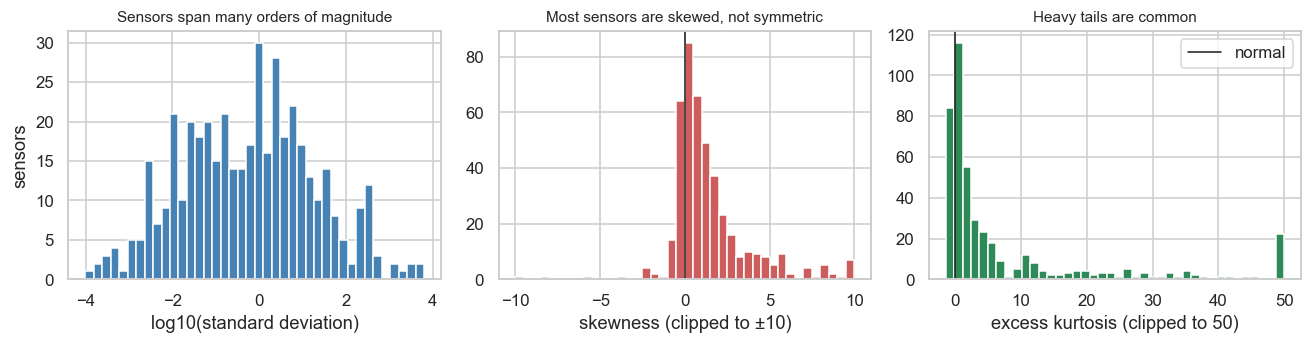

sensors with |skew| > 2      : 118 of 436
sensors with kurtosis > 10   : 96
std ranges from 9.84e-05 to 6.32e+03


In [4]:
# How are the sensors distributed in shape and scale?
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2))

ax[0].hist(np.log10(prof["std"].replace(0, np.nan).dropna()), bins=40, color="steelblue")
ax[0].set_xlabel("log10(standard deviation)"); ax[0].set_ylabel("sensors")
ax[0].set_title("Sensors span many orders of magnitude")

ax[1].hist(prof["skew"].clip(-10, 10), bins=40, color="indianred")
ax[1].axvline(0, color="k", lw=1)
ax[1].set_xlabel("skewness (clipped to ±10)")
ax[1].set_title("Most sensors are skewed, not symmetric")

ax[2].hist(prof["kurtosis"].clip(-5, 50), bins=40, color="seagreen")
ax[2].axvline(0, color="k", lw=1, label="normal")
ax[2].set_xlabel("excess kurtosis (clipped to 50)")
ax[2].set_title("Heavy tails are common"); ax[2].legend()
plt.tight_layout(); plt.show()

print(f"sensors with |skew| > 2      : {(prof['skew'].abs() > 2).sum()} of {len(prof)}")
print(f"sensors with kurtosis > 10   : {(prof['kurtosis'] > 10).sum()}")
print(f"std ranges from {prof['std'].min():.2e} to {prof['std'].max():.2e}")

**Three findings that shape everything downstream.**

Most sensors are skewed rather than symmetric, and many have heavy tails even after the winsorization
applied during wrangling. This matters for test selection in §3: a t-test assumes approximate
normality of the sampling distribution, so a rank-based test is needed as a cross-check.

 How many sensors fail the Shapiro–Wilk normality test?

    H₀ (null hypothesis): the data is normally distributed.

    H₁: the data is not normally distributed.

With the common threshold of 0.05:

In [5]:
# Normality check on a random sample of sensors (Shapiro-Wilk)
rng = np.random.default_rng(42)
sample = rng.choice(SENSORS, size=60, replace=False)
sw = pd.Series({s: stats.shapiro(train[s].sample(500, random_state=0))[1] for s in sample})

print(f"Shapiro-Wilk on 60 randomly chosen sensors:")
print(f"  reject normality at p < 0.05 : {(sw < 0.05).sum()} of {len(sw)}")
print(f"  median p-value               : {sw.median():.2e}")
print("\n=> normality cannot be assumed; §3 reports a rank-based test alongside the t-test.")

Shapiro-Wilk on 60 randomly chosen sensors:
  reject normality at p < 0.05 : 57 of 60
  median p-value               : 6.36e-18

=> normality cannot be assumed; §3 reports a rank-based test alongside the t-test.


---
### 2.1 The response variable

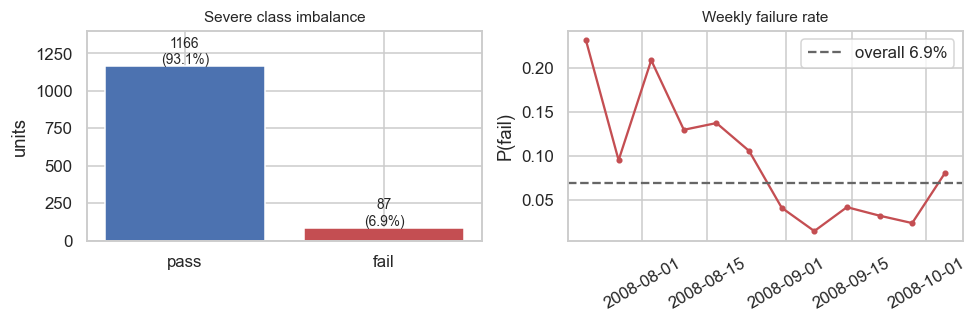

imbalance ratio: 13.4 passes per failure


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
counts = y.value_counts().sort_index()
ax[0].bar(["pass", "fail"], counts.values, color=["#4C72B0", "#C44E52"])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 15, f"{v}\n({v/len(y):.1%})", ha="center", fontsize=9)
ax[0].set_ylabel("units"); ax[0].set_title("Severe class imbalance")
ax[0].set_ylim(0, counts.max() * 1.2)

monthly = train.set_index("timestamp").resample("W")["fail"].mean()
ax[1].plot(monthly.index, monthly.values, marker="o", ms=3, color="#C44E52")
ax[1].axhline(y.mean(), ls="--", color="0.4", label=f"overall {y.mean():.1%}")
ax[1].set_title("Weekly failure rate"); ax[1].set_ylabel("P(fail)")
ax[1].tick_params(axis="x", rotation=30); ax[1].legend()
plt.tight_layout(); plt.show()

print(f"imbalance ratio: {(1-y).sum() / y.sum():.1f} passes per failure")

The imbalance is the single most important characteristic of this dataset. Three consequences:

- **Accuracy is a useless metric.** Predicting "pass" for every unit scores 93.1%.
- **Precision, recall, and PR-AUC** are the metrics that mean something here. ROC-AUC is optimistic
  under heavy imbalance because the large negative class makes the false-positive rate move slowly.
- **Statistical power is limited by the 87 failures**, not by the 1,253 units. Every test below is
  effectively a small-sample test.

---
## 3. Inferential statistics — which sensors separate pass from fail?

**Hypotheses.** For each sensor $j$:

> $H_0$: the distribution of sensor $j$ is the same for failing and passing units.
> $H_1$: the distributions differ.

**Tests used, and why two.** Welch's t-test compares means without assuming equal variances — the
right choice given that the two groups differ enormously in size. But §2 showed the sensors are
skewed and heavy-tailed, so the Mann-Whitney U test is run alongside it. It compares distributions
by rank, needs no distributional assumption, and is far less influenced by extreme values. Where the
two agree, the finding is solid; where they disagree, the difference is being driven by tails rather
than by a genuine shift in the bulk of the distribution.

**Multiple comparisons.** Testing 436 sensors at α = 0.05 would yield roughly 22 false positives
even if no sensor mattered at all. Benjamini–Hochberg FDR control is applied so that the reported
discoveries have a controlled expected false-discovery proportion. BH is used rather than Bonferroni
because the goal here is a candidate list for modelling, not a definitive claim about each sensor —
FDR keeps power up.

**Effect size.** A p-value only says whether a difference is detectable; it says nothing about
whether the difference is large enough to be useful. Cohen's *d* is reported for each sensor, plus
the point-biserial correlation with the label.

#### Sensor Analysis Workflow

```text
                 SENSOR DATA
                      │
             ┌────────┴────────┐
             │                 │
          Failure            Pass
           y = 1             y = 0
             │                 │
             └────────┬────────┘
                      │
              Compare each sensor
                      │
        ┌─────────────┼─────────────┐
        │             │             │
   Welch t-test   Mann-Whitney   Cohen's d
        │             │             │
      p-value       p-value      effect size
        │             │
        └──────┬──────┘
               │
        Benjamini-Hochberg
             FDR correction
               │
               ▼
       Significant sensors
               │
               ▼
     Identify sensors associated
          with failures

In [7]:
def bh_fdr(p):
    # Benjamini-Hochberg adjusted p-values
    p = np.asarray(p, dtype=float)
    n = len(p)
    order = np.argsort(p)
    adj = np.empty(n)
    adj[order] = np.minimum.accumulate((p[order] * n / np.arange(1, n + 1))[::-1])[::-1]
    return np.clip(adj, 0, 1)

fail_mask = y == 1
rows = []
for s in SENSORS:
    a, b = train.loc[fail_mask, s], train.loc[~fail_mask, s]
    if a.nunique() <= 1 and b.nunique() <= 1:
        continue
    t_stat, t_p = stats.ttest_ind(a, b, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")
    # Cohen's d with pooled SD
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    d = (a.mean() - b.mean()) / sp if sp > 0 else 0.0
    r_pb, r_p = stats.pointbiserialr(y, train[s])
    rows.append({"sensor": s, "mean_fail": a.mean(), "mean_pass": b.mean(),
                 "cohens_d": d, "t_p": t_p, "mw_p": u_p, "r_pb": r_pb})

tests = pd.DataFrame(rows)
tests["t_p_fdr"]  = bh_fdr(tests.t_p)
tests["mw_p_fdr"] = bh_fdr(tests.mw_p)
tests["abs_d"] = tests.cohens_d.abs()
tests = tests.sort_values("t_p_fdr").reset_index(drop=True)

print(f"sensors tested                          : {len(tests)}")
print(f"significant, Welch t-test  (FDR < 0.05) : {(tests.t_p_fdr < ALPHA).sum()}")
print(f"significant, Mann-Whitney  (FDR < 0.05) : {(tests.mw_p_fdr < ALPHA).sum()}")
print(f"significant on BOTH tests               : {((tests.t_p_fdr < ALPHA) & (tests.mw_p_fdr < ALPHA)).sum()}")
print(f"\nuncorrected p < 0.05 (for contrast)     : {(tests.t_p < ALPHA).sum()}"
      f"   <- ~{int(0.05*len(tests))} expected by chance alone")

sensors tested                          : 436
significant, Welch t-test  (FDR < 0.05) : 15
significant, Mann-Whitney  (FDR < 0.05) : 20
significant on BOTH tests               : 9

uncorrected p < 0.05 (for contrast)     : 79   <- ~21 expected by chance alone


In [8]:
sig = tests[(tests.t_p_fdr < ALPHA) | (tests.mw_p_fdr < ALPHA)].copy()
print(f"Sensors significant on at least one test: {len(sig)}\n")
display(sig.head(15)[["sensor", "mean_fail", "mean_pass", "cohens_d", "r_pb",
                      "t_p_fdr", "mw_p_fdr"]].round(4))

Sensors significant on at least one test: 26



,sensor,mean_fail,mean_pass,cohens_d,r_pb,t_p_fdr,mw_p_fdr
0,S059,10.0319,3.2147,0.7937,0.1979,0.0000,0.0000
1,S129,-0.1209,-0.6671,0.4268,0.1079,0.0000,0.0141
2,S125,1.0816,1.1797,-0.3489,-0.0884,0.0062,0.0959
3,S103,-0.0081,-0.0096,0.5191,0.1309,0.0062,0.0006
4,S028,67.6462,69.0524,-0.4116,-0.1042,0.0111,0.0151
5,S477,7.1061,5.7404,0.5523,0.1391,0.0111,0.0036
6,S280,0.0161,0.0178,-0.2715,-0.0689,0.0111,0.1474
7,S341,3.0825,2.5363,0.5745,0.1446,0.0111,0.0050
8,S205,10.4936,8.4749,0.5494,0.1384,0.0112,0.0036
9,S122,3.6151,3.9163,-0.3254,-0.0825,0.0128,0.1028


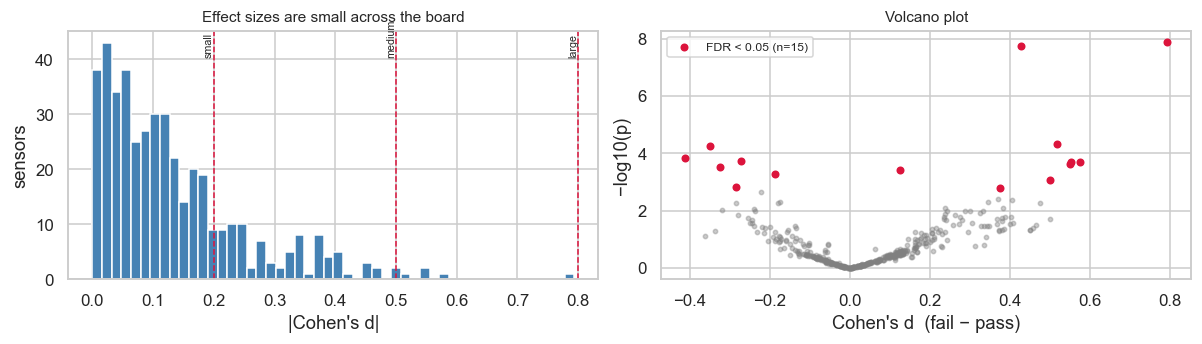

largest |d| : 0.794  (S059)
median |d|  : 0.102
sensors with |d| > 0.5 : 7


In [9]:
# Where do the effect sizes sit? Cohen's conventions: 0.2 small, 0.5 medium, 0.8 large.
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))

ax[0].hist(tests.abs_d, bins=50, color="steelblue")
for v, lab in [(0.2, "small"), (0.5, "medium"), (0.8, "large")]:
    ax[0].axvline(v, ls="--", lw=1, color="crimson")
    ax[0].text(v, ax[0].get_ylim()[1]*0.9, lab, rotation=90, fontsize=7, ha="right")
ax[0].set_xlabel("|Cohen's d|"); ax[0].set_ylabel("sensors")
ax[0].set_title("Effect sizes are small across the board")

# Volcano plot: effect size against significance
ax[1].scatter(tests.cohens_d, -np.log10(tests.t_p), s=8, alpha=0.4, color="0.5")
hit = tests.t_p_fdr < ALPHA
ax[1].scatter(tests.cohens_d[hit], -np.log10(tests.t_p[hit]), s=18, color="crimson",
              label=f"FDR < {ALPHA} (n={hit.sum()})")
ax[1].set_xlabel("Cohen's d  (fail − pass)"); ax[1].set_ylabel("−log10(p)")
ax[1].set_title("Volcano plot"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"largest |d| : {tests.abs_d.max():.3f}  ({tests.loc[tests.abs_d.idxmax(), 'sensor']})")
print(f"median |d|  : {tests.abs_d.median():.3f}")
print(f"sensors with |d| > 0.5 : {(tests.abs_d > 0.5).sum()}")

A handful of sensors do reach a respectable effect size — the strongest is close to Cohen's "large"
threshold, and seven exceed the "medium" mark. But the median effect across all 436 sensors is near
zero, and only a small minority survive FDR correction at all. **No single sensor comes close to
separating failing from passing units on its own.** If one did, this problem would be solved with a
control chart and would not need machine learning.

The practical implication: a workable model has to pool weak signals across many sensors rather than
lean on a few strong ones. That points toward regularised linear models and tree ensembles, and away
from expecting a simple interpretable rule. It also sets a realistic performance expectation — a
model that catches even a modest share of failures at usable precision is valuable on a line where
each missed failure is a scrapped unit.

The volcano plot makes the multiple-comparisons problem concrete. Far more sensors clear an
uncorrected p < 0.05 than survive FDR correction, and the uncorrected count is close to what pure
chance would produce across 436 tests. Reporting that number would have been a serious overstatement.

---
### 3.1 Do the missing-value indicators carry signal?

#### Chi-Square Test of Independence

The chi-square test of independence asks:

> **Is sensor missingness independent of failure?**

**Hypotheses:**

- **H₀ (Null Hypothesis):** Sensor missingness and failure are independent.
- **H₁ (Alternative Hypothesis):** Sensor missingness and failure are associated.

**Decision rule:**

- If **p < 0.05**, reject H₀.
- If **p ≥ 0.05**, fail to reject H₀.

Therefore, when **p < 0.05**, there is statistically significant evidence that **sensor missingness is associated with failure**.


In [10]:
# Chi-square test: is a sensor being offline associated with failure?
flag_rows = []
for f in FLAGS:
    tab = pd.crosstab(train[f], y)
    if tab.shape == (2, 2) and tab.values.min() >= 1:
        chi2, p, _, _ = stats.chi2_contingency(tab)
        rate_missing = y[train[f] == 1].mean()
        rate_present = y[train[f] == 0].mean()
        flag_rows.append({"flag": f, "n_missing": int(train[f].sum()),
                          "fail_rate_missing": rate_missing,
                          "fail_rate_present": rate_present,
                          "lift": rate_missing / rate_present if rate_present else np.nan,
                          "p": p})

flags_df = pd.DataFrame(flag_rows).sort_values("p")
if len(flags_df):
    flags_df["p_fdr"] = bh_fdr(flags_df.p)
    n_sig = (flags_df.p_fdr < ALPHA).sum()
    print(f"missing-indicators tested: {len(flags_df)}  |  significant (FDR < {ALPHA}): {n_sig}\n")
    display(flags_df.head(8).round(4))

missing-indicators tested: 28  |  significant (FDR < 0.05): 8



,flag,n_missing,fail_rate_missing,fail_rate_present,lift,p,p_fdr
0,S072_isna,574,0.0401,0.0943,0.4251,0.0003,0.0018
1,S073_isna,574,0.0401,0.0943,0.4251,0.0003,0.0018
5,S346_isna,574,0.0401,0.0943,0.4251,0.0003,0.0018
4,S345_isna,574,0.0401,0.0943,0.4251,0.0003,0.0018
3,S247_isna,422,0.0427,0.0830,0.5137,0.0111,0.0388
2,S112_isna,422,0.0427,0.0830,0.5137,0.0111,0.0388
6,S385_isna,422,0.0427,0.0830,0.5137,0.0111,0.0388
7,S519_isna,422,0.0427,0.0830,0.5137,0.0111,0.0388


This is why the data-wrangling notebook retained the missingness indicators instead of silently imputing the missing values. When a flag is statistically significant, it suggests that **the sensor going offline is associated with unit failure**. This may occur because the same underlying equipment or process fault that causes the sensor to stop recording also contributes to the failure. Simply imputing the missing values would remove this potentially important information.

---
## 4. Data visualisation - what do the relationships look like?

Numbers established *which* sensors differ. Plots establish *how*, and guard against being misled:
a significant t-test can be produced by three outliers, by a bimodal split, or by a genuine shift,
and only a plot tells them apart.

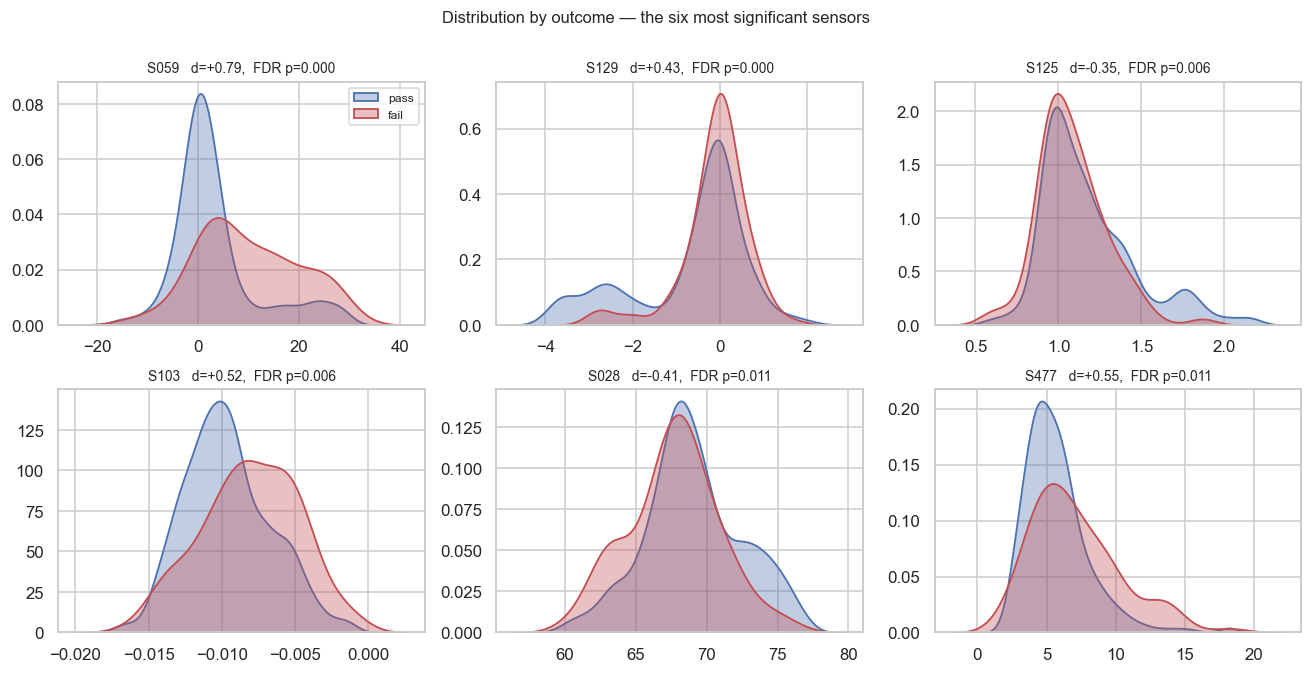

In [11]:
top6 = tests.nsmallest(6, "t_p_fdr").sensor.tolist()

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, s in zip(axes.ravel(), top6):
    for lab, colour in [(0, "#4C72B0"), (1, "#C44E52")]:
        sns.kdeplot(train.loc[y == lab, s], ax=ax, fill=True, alpha=0.35,
                    color=colour, label="fail" if lab else "pass", lw=1.2)
    r = tests.loc[tests.sensor == s].iloc[0]
    ax.set_title(f"{s}   d={r.cohens_d:+.2f},  FDR p={r.t_p_fdr:.3f}", fontsize=9)
    ax.set_xlabel(""); ax.set_ylabel("")
axes[0, 0].legend(fontsize=8)
plt.suptitle("Distribution by outcome — the six most significant sensors", y=1.01)
plt.tight_layout(); plt.show()

The overlap between the two curves is the story. Even for the most significant sensors the
distributions sit almost on top of each other, with only a modest shift in centre or spread. This is
the visual counterpart of the small effect sizes — and it is why a threshold rule on any single
sensor would misclassify heavily.

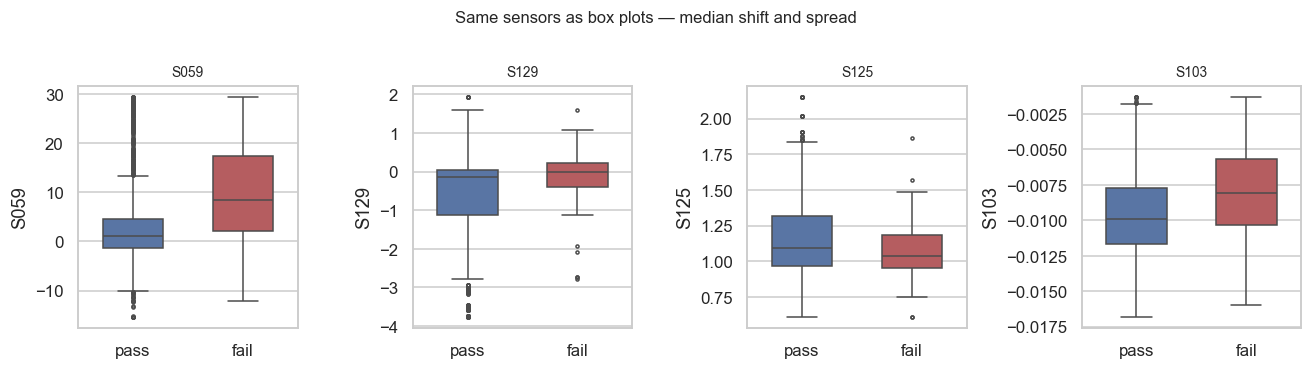

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, s in zip(axes, top6[:4]):
    sns.boxplot(x=y.map({0: "pass", 1: "fail"}), y=train[s], ax=ax,
                palette=["#4C72B0", "#C44E52"], width=0.55, fliersize=2)
    ax.set_title(s, fontsize=9); ax.set_xlabel("")
plt.suptitle("Same sensors as box plots — median shift and spread", y=1.03)
plt.tight_layout(); plt.show()

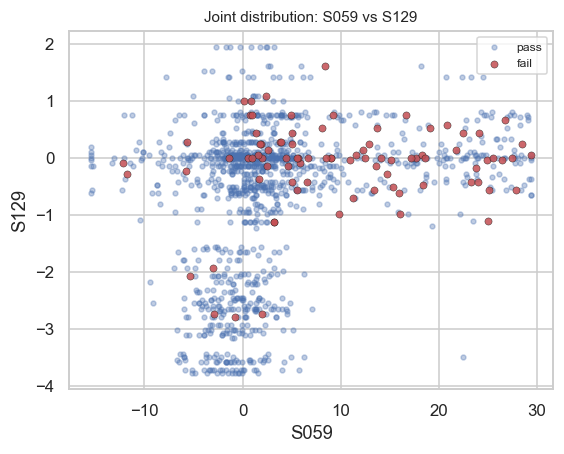

Failures are scattered through the passing cloud rather than occupying a distinct region -
no two-sensor rule will separate them. A model needs many features at once.


In [13]:
# Bi-plot: do two weak sensors separate the classes better together than alone?
s1, s2 = top6[0], top6[1]
fig, ax = plt.subplots(figsize=(5.2, 4.2))
ax.scatter(train.loc[y == 0, s1], train.loc[y == 0, s2], s=10, alpha=0.35,
           color="#4C72B0", label="pass")
ax.scatter(train.loc[y == 1, s1], train.loc[y == 1, s2], s=22, alpha=0.85,
           color="#C44E52", edgecolor="k", linewidth=0.3, label="fail")
ax.set_xlabel(s1); ax.set_ylabel(s2)
ax.set_title(f"Joint distribution: {s1} vs {s2}")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("Failures are scattered through the passing cloud rather than occupying a distinct region -")
print("no two-sensor rule will separate them. A model needs many features at once.")

---
## 5. Correlation structure among the sensors

In [14]:
corr = train[SENSORS].corr()
corr.head()

,S000,S001,S002,S003,S004,S006,S007,S008,S009,S010,S011,S012,S014,S015,S016,...,S570,S571,S572,S573,S574,S575,S576,S577,S582,S583,S584,S586,S587,S588,S589
S000,1.000000,-0.151217,-0.000829,0.020855,0.010036,-0.030947,-0.011142,-0.049262,0.002755,0.007675,0.084798,0.005023,-0.009845,-0.035825,-0.035710,...,-0.018797,-0.033009,0.025702,0.003572,0.027731,0.013149,0.024439,0.015595,-0.000164,-0.025133,-0.037256,0.023798,-0.029072,-0.029684,-0.009639
S001,-0.151217,1.000000,0.020511,-0.031624,0.020512,-0.028437,0.006805,0.010139,0.032345,-0.012952,-0.044089,0.049546,-0.046686,-0.025634,0.000874,...,-0.012731,-0.045231,0.026165,0.005450,0.023148,0.003812,0.024686,0.012612,0.046102,0.035721,0.023488,-0.015850,0.027907,0.026520,0.066280
S002,-0.000829,0.020511,1.000000,0.440723,-0.001004,-0.208646,-0.419887,0.001731,0.019285,0.057418,0.041620,0.014150,0.013099,0.004455,-0.084487,...,-0.037051,-0.005548,-0.008800,-0.036704,-0.007027,-0.038715,-0.004424,-0.038174,0.011817,0.008704,0.016001,-0.029848,-0.041855,-0.046364,-0.044028
S003,0.020855,-0.031624,0.440723,1.000000,0.298019,-0.696828,0.195465,-0.061214,0.094416,0.041513,0.048915,-0.040016,-0.096603,-0.062102,-0.075009,...,-0.002063,-0.004224,0.022867,0.012852,0.021462,0.001260,0.022414,0.012446,-0.006559,-0.038703,-0.043506,0.068114,-0.045920,-0.041380,-0.093485
S004,0.010036,0.020512,-0.001004,0.298019,1.000000,-0.328108,0.015295,-0.003633,0.032553,0.000441,-0.006527,-0.040266,-0.056178,-0.049270,-0.034417,...,-0.037714,0.021512,0.022521,0.025481,0.025421,0.028823,0.024887,0.027286,0.080652,0.020024,0.003705,0.046782,0.029061,0.036428,0.002089


In [15]:
corr = train[SENSORS].corr()
abs_corr = corr.abs().mask(np.eye(len(SENSORS), dtype=bool))   # blank the diagonal

pairs = (abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
                 .stack().sort_values(ascending=False))

print("Pairwise |Pearson r| among 436 sensors")
print(f"  pairs                : {len(pairs):,}")
print(f"  median |r|           : {pairs.median():.3f}")
for t in [0.7, 0.8, 0.9, 0.95]:
    print(f"  pairs with |r| > {t}  : {(pairs > t).sum():,}")
print(f"\nsensors with at least one partner above 0.9: "
      f"{(abs_corr.max() > 0.9).sum()} of {len(SENSORS)}")
print("\nStrongest pairs:")
display(pairs.head(8).to_frame("abs_r").round(4))

Pairwise |Pearson r| among 436 sensors
  pairs                : 94,830
  median |r|           : 0.030
  pairs with |r| > 0.7  : 497
  pairs with |r| > 0.8  : 400
  pairs with |r| > 0.9  : 288
  pairs with |r| > 0.95  : 216

sensors with at least one partner above 0.9: 298 of 436

Strongest pairs:


,,abs_r
S254,S526,1.0000
S251,S523,1.0000
S222,S494,1.0000
S155,S428,1.0000
S153,S426,0.9999
S176,S447,0.9999
S268,S540,0.9999
S195,S467,0.9999


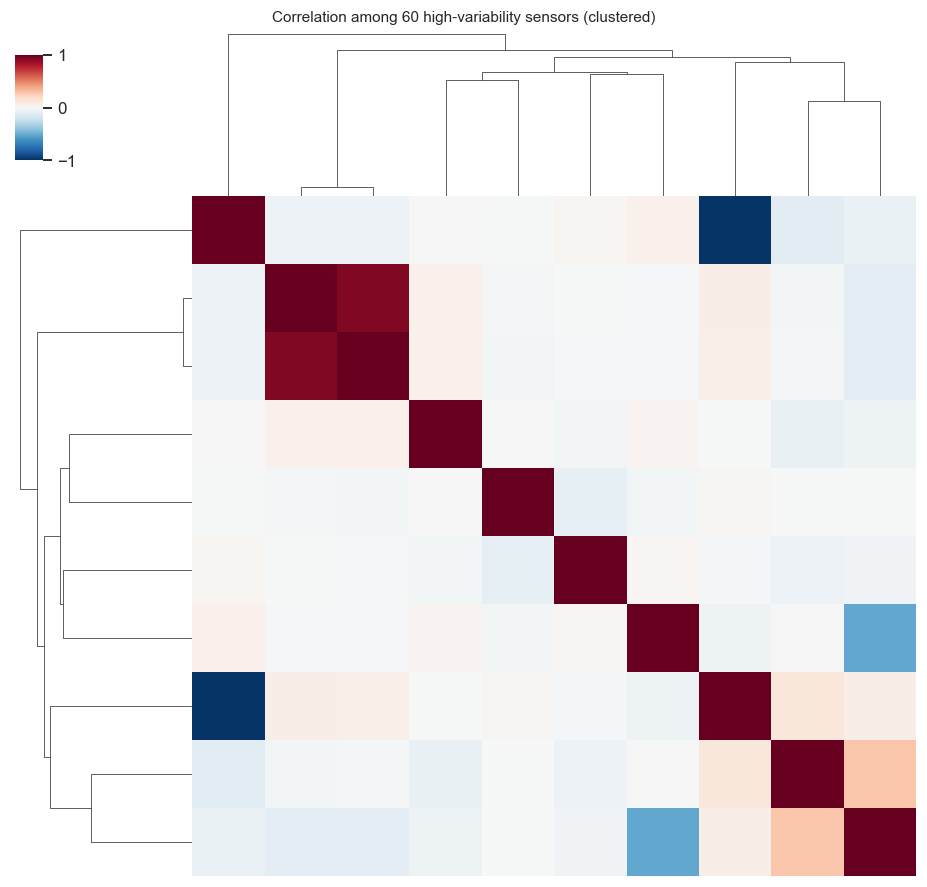

In [16]:
# Cluster the 10 most variable sensors to show the block structure
top_var = prof.nlargest(10, "cv").index.tolist()
sub = train[top_var].corr()

g = sns.clustermap(sub, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                   figsize=(8.5, 8), xticklabels=False, yticklabels=False,
                   cbar_pos=(0.02, 0.83, 0.03, 0.12))
g.figure.suptitle("Correlation among 60 high-variability sensors (clustered)", y=1.0, fontsize=10)
plt.show()

**The correlation structure is local, not global.** The median pairwise correlation is essentially
zero — most sensor pairs are unrelated, as you would expect from measurements taken at different
stages of a long process. But roughly two-thirds of sensors have at least one partner correlated
above 0.9, and the clustermap shows why: the redundancy is concentrated in tight blocks, almost
certainly measurements from the same tool, chamber, or process step.

That pattern has three consequences:

- **Linear models will be unstable.** Within a block, correlated predictors split coefficient weight
  arbitrarily between themselves, so signs and magnitudes cannot be read directly. L2 or elastic-net
  regularisation handles this; plain logistic regression does not.
- **Tree-based importance will be diluted.** Where five sensors carry the same information, each
  receives a fraction of the importance, and all five can look unimportant.
- **The effective dimensionality is well below 436.** Encouraging, given only 87 failures — the model
  does not need to learn 436 independent relationships.

---
## 6. Feature selection and engineering

Selection here means producing a **ranked candidate list**, not a final feature set. The actual
selection must happen inside the cross-validation loop, because choosing features using the labels
of all 1,253 training units and then cross-validating on those same units gives an optimistic score.
What is built below is the ranking and the engineered columns; the cut-off is a modelling decision.

### 6.1 Ranking the existing features

In [17]:
ranking = tests[["sensor", "abs_d", "r_pb", "t_p_fdr", "mw_p_fdr"]].copy()
ranking["neg_log_p"] = -np.log10(tests.t_p.clip(lower=1e-300))

# Combine three views: effect size, correlation with the label, and significance.
for col in ["abs_d", "neg_log_p"]:
    ranking[f"{col}_rank"] = ranking[col].rank(ascending=False)
ranking["r_pb_rank"] = ranking.r_pb.abs().rank(ascending=False)
ranking["score"] = ranking[["abs_d_rank", "neg_log_p_rank", "r_pb_rank"]].mean(axis=1)
ranking = ranking.sort_values("score").reset_index(drop=True)

print("Top 15 candidate sensors (consensus of effect size, correlation, and significance)\n")
display(ranking.head(15)[["sensor", "abs_d", "r_pb", "t_p_fdr", "score"]].round(4))
ranking.to_csv(OUT / "eda_feature_ranking.csv", index=False)

Top 15 candidate sensors (consensus of effect size, correlation, and significance)



,sensor,abs_d,r_pb,t_p_fdr,score
0,S059,0.7937,0.1979,0.0000,1.0000
1,S341,0.5745,0.1446,0.0111,3.6667
2,S103,0.5191,0.1309,0.0062,4.3333
3,S477,0.5523,0.1391,0.0111,4.6667
4,S205,0.5494,0.1384,0.0112,5.6667
5,S510,0.5016,0.1266,0.0295,8.3333
6,S129,0.4268,0.1079,0.0000,9.3333
7,S028,0.4116,-0.1042,0.0111,11.0000
8,S021,0.4748,0.1199,0.1051,13.0000
9,S333,0.4050,0.1025,0.1036,16.6667


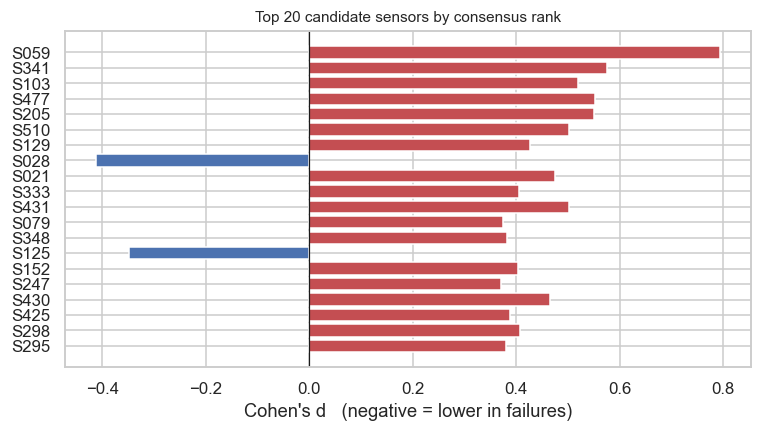

In [18]:
fig, ax = plt.subplots(figsize=(7, 4))
top20 = ranking.head(20).iloc[::-1]
colours = ["#C44E52" if v > 0 else "#4C72B0" for v in
           tests.set_index("sensor").loc[top20.sensor, "cohens_d"]]
ax.barh(top20.sensor, tests.set_index("sensor").loc[top20.sensor, "cohens_d"], color=colours)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Cohen's d   (negative = lower in failures)")
ax.set_title("Top 20 candidate sensors by consensus rank")
plt.tight_layout(); plt.show()

### 6.2 Multivariate selection with L1 (lasso) logistic regression

§6.1 ranked sensors **one at a time**. That has a blind spot: a univariate screen cannot tell whether
two highly-ranked sensors carry the *same* information, and it cannot see a sensor that only becomes
useful once another is held constant. Given the correlated blocks found in §5, the univariate list is
almost certainly full of duplicates.

L1-penalised logistic regression fits all features jointly and penalises the sum of absolute
coefficients, which drives most of them exactly to zero. What survives is a subset that is *jointly*
predictive — redundant partners get dropped rather than counted twice.

Three settings matter here. **Standardisation** is mandatory, because §2 showed the sensors span
orders of magnitude and the L1 penalty acts on the raw coefficient scale. **`class_weight="balanced"`**
stops the 6.9% failure rate from collapsing the fit to "predict pass, zero everything".
**`TimeSeriesSplit`** trains on earlier units and scores on later ones, because §6 documented drift;
tuning targets PR-AUC, per §2.1.

In [19]:
plt.rcParams["mathtext.fontset"] = "dejavusans"   # Computer Modern is missing locally

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

FEATURES = SENSORS + FLAGS
order  = train.sort_values("timestamp").index
X      = train.loc[order, FEATURES]
y_ord  = train.loc[order, "fail"].to_numpy()

l1_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
    ("clf",    LogisticRegression(penalty="l1", solver="liblinear",
                                  class_weight="balanced", max_iter=5000,
                                  random_state=0)),
])

cv = TimeSeriesSplit(n_splits=5)
Cs = np.logspace(-3, 1, 25)

search = GridSearchCV(l1_pipe, {"clf__C": Cs}, scoring="average_precision",
                      cv=cv, n_jobs=-1, refit=True)
search.fit(X, y_ord)

C_best    = search.best_params_["clf__C"]
coef_best = search.best_estimator_.named_steps["clf"].coef_.ravel()

print(f"features offered to L1          : {len(FEATURES)}  "
      f"({len(SENSORS)} sensors + {len(FLAGS)} missing-flags)")
print(f"best C (time-ordered CV, PR-AUC): {C_best:.4g}")
print(f"cross-validated PR-AUC          : {search.best_score_:.4f}"
      f"   (no-skill baseline = {y_ord.mean():.4f})")
print(f"non-zero coefficients at C*     : {(coef_best != 0).sum()} of {len(FEATURES)}")

features offered to L1          : 464  (436 sensors + 28 missing-flags)
best C (time-ordered CV, PR-AUC): 0.02154
cross-validated PR-AUC          : 0.1408   (no-skill baseline = 0.0694)
non-zero coefficients at C*     : 32 of 464


Of 464 candidate features, only **32 survive at the best penalty**, and the
cross-validated PR-AUC is **0.141 against a no-skill baseline of 0.069** — roughly a 2× lift. That is
a real signal but a modest one, exactly consistent with the small effect sizes in §3.

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


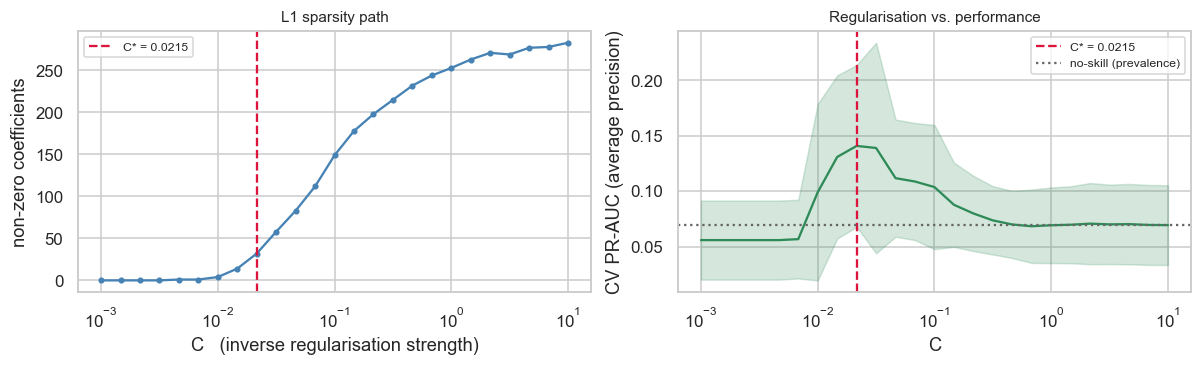

features kept at C* : 32
PR-AUC lift over prevalence : 2.03x


In [21]:
path_rows = []
for C in Cs:
    p = l1_pipe.set_params(clf__C=C).fit(X, y_ord)
    path_rows.append({"C": C,
                      "n_nonzero": int((p.named_steps["clf"].coef_ != 0).sum())})
path = pd.DataFrame(path_rows)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
                     "mathtext.fontset": "dejavusans"})
ax[0].semilogx(path.C, path.n_nonzero, marker="o", ms=3, color="steelblue")
ax[0].axvline(C_best, ls="--", color="crimson", label=f"C* = {C_best:.3g}")
ax[0].set_xlabel("C   (inverse regularisation strength)")
ax[0].set_ylabel("non-zero coefficients")
ax[0].set_title("L1 sparsity path"); ax[0].legend(fontsize=8)

m = search.cv_results_["mean_test_score"]
s = search.cv_results_["std_test_score"]
ax[1].semilogx(Cs, m, color="seagreen")
ax[1].fill_between(Cs, m - s, m + s, alpha=0.2, color="seagreen")
ax[1].axvline(C_best, ls="--", color="crimson", label=f"C* = {C_best:.3g}")
ax[1].axhline(y_ord.mean(), ls=":", color="0.4", label="no-skill (prevalence)")
ax[1].set_xlabel("C"); ax[1].set_ylabel("CV PR-AUC (average precision)")
ax[1].set_title("Regularisation vs. performance"); ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"features kept at C* : {path.loc[path.C == C_best, 'n_nonzero'].iloc[0]}")
print(f"PR-AUC lift over prevalence : {search.best_score_ / y_ord.mean():.2f}x")

**Reading the two panels.** The left panel is the sparsity path: how many
features survive as the penalty relaxes. The right panel shows what that sparsity buys, with the
shaded band giving fold-to-fold spread; the gap between the curve and the dotted line is the entire
predictive signal in this dataset.

The important feature is that performance *peaks* at a strong penalty and falls off as more features
are admitted. Those extra features are fitting noise. This is the same conclusion §3 reached from the
effect sizes, arrived at independently — the signal is weak, distributed, and low-dimensional
relative to 436 sensors.

In [ ]:
N_BOOT, FRAC, PI = 200, 0.75, 0.60

sel_count = np.zeros(len(FEATURES))
coef_sum  = np.zeros(len(FEATURES))
rng_ss    = np.random.default_rng(0)

for b in range(N_BOOT):
    idx = rng_ss.choice(len(X), size=int(FRAC * len(X)), replace=False)
    Xi, yi = X.iloc[idx], y_ord[idx]
    if yi.sum() < 5:
        continue
    c = (l1_pipe.set_params(clf__C=C_best)
                .fit(Xi, yi)
                .named_steps["clf"].coef_.ravel())
    sel_count += (c != 0)
    coef_sum  += np.abs(c)

stab = (pd.DataFrame({"feature":       FEATURES,
                      "sel_freq":      sel_count / N_BOOT,
                      "mean_abs_coef": coef_sum / N_BOOT,
                      "coef_at_Cstar": coef_best,
                      "is_flag":       [f in FLAGS for f in FEATURES]})
          .sort_values(["sel_freq", "mean_abs_coef"], ascending=False)
          .reset_index(drop=True))

stable = stab[stab.sel_freq >= PI]

print(f"bootstrap refits                 : {N_BOOT}  ({FRAC:.0%} subsamples)")
print(f"selected in >= {PI:.0%} of refits    : {len(stable)} features")
print(f"   of which sensors              : {(~stable.is_flag).sum()}")
print(f"   of which missing-flags        : {stable.is_flag.sum()}")
print(f"never selected in any refit      : {(stab.sel_freq == 0).sum()} of {len(FEATURES)}\n")
display(stable.head(20).round(4))

#### Why stability selection

A single lasso fit is a fragile basis for a feature list. Within a correlated block, which member
receives the non-zero coefficient is close to arbitrary — resample the rows and a different partner
wins. With only 87 failures, dropping a handful changes the subset substantially.

Stability selection (Meinshausen & Bühlmann, 2010) measures that fragility instead of ignoring it:
refit on many random 75% subsamples and score each feature by **how often** it is kept. A feature
chosen in 95% of refits is a finding; one chosen in 20% won a coin-flip among block partners.

**15 features clear the 60% threshold** — 11 sensors and 4 missing-flags — while **293 of 464 are
never selected at all**. S059 is selected in every single refit, and S021 and S064 in over 95%. Those
three are solid. The features near the threshold are block representatives whose identity is
essentially interchangeable.

The 4 missing-flags in the list confirm §3.1 from a different direction: sensor *downtime* carries
signal that survives when competing against all 436 readings at once.

In [ ]:
top = stab.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 5))
colours = ["#C44E52" if v > 0 else "#4C72B0" for v in top.coef_at_Cstar]
ax.barh(top.feature, top.sel_freq, color=colours)
ax.axvline(PI, ls="--", color="k", lw=1, label=f"stability threshold {PI:.0%}")
ax.set_xlabel("selection frequency across bootstrap refits")
ax.set_xlim(0, 1)
ax.set_title("Top 20 features by L1 stability selection\n"
             "(red = higher in failures, blue = lower)", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
l1_sensors = stab[~stab.is_flag].reset_index(drop=True)

cmp_ = (ranking[["sensor", "score", "abs_d", "t_p_fdr"]]
        .merge(l1_sensors.rename(columns={"feature": "sensor"})
                          [["sensor", "sel_freq", "mean_abs_coef"]],
               on="sensor", how="left"))
cmp_["univ_rank"] = cmp_["score"].rank()
cmp_["l1_rank"]   = cmp_["sel_freq"].rank(ascending=False)

rho = cmp_[["univ_rank", "l1_rank"]].corr(method="spearman").iloc[0, 1]
K = 30
univ_top = set(ranking.head(K).sensor)
l1_top   = set(l1_sensors.head(K).feature)

print(f"Spearman rho, univariate rank vs L1 stability rank : {rho:+.3f}")
print(f"overlap in the top {K}                              : {len(univ_top & l1_top)} of {K}")
print(f"\nfound by L1 but NOT in the univariate top {K}:")
print("  ", sorted(l1_top - univ_top))
print(f"\nin the univariate top {K} but not selected by L1:")
print("  ", sorted(univ_top - l1_top))

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(cmp_.abs_d, cmp_.sel_freq, s=12, alpha=0.5, color="0.4")
hit = cmp_.sel_freq >= PI
ax.scatter(cmp_.abs_d[hit], cmp_.sel_freq[hit], s=30, color="crimson",
           label=f"stable (>= {PI:.0%})")
ax.axhline(PI, ls="--", color="k", lw=0.8)
ax.set_xlabel("|Cohen's d|   (univariate effect size, §3)")
ax.set_ylabel("L1 selection frequency")
ax.set_title("Univariate effect vs. multivariate stability", fontsize=10)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

**The two rankings agree only moderately** — Spearman ρ = +0.44, with 10 of
30 shared in the top 30. That divergence is itself the finding. Twenty sensors selected by L1 never
appear in the univariate top 30: they matter only in combination, and a univariate screen would have
missed them entirely. Twenty univariate favourites are dropped by L1, most likely because a block
partner already carries their information.

In [ ]:
out = (stab.merge(tests[["sensor", "cohens_d", "t_p_fdr", "mw_p_fdr"]]
                       .rename(columns={"sensor": "feature"}),
                  on="feature", how="left")
           .merge(ranking[["sensor", "score"]]
                       .rename(columns={"sensor": "feature", "score": "univariate_rank"}),
                  on="feature", how="left"))
out.to_csv(OUT / "eda_l1_feature_selection.csv", index=False)

print(f"saved {OUT / 'eda_l1_feature_selection.csv'}  ({len(out)} rows)")
print(f"\ncandidate feature set for modelling (sel_freq >= {PI:.0%}): {len(stable)} features")
print(", ".join(stable.feature.tolist()))

**What §6.2 delivers, and what it deliberately does not.**

For modelling, the L1 list is the more relevant one: those features earn their place conditional on
everything else, which is the situation a model actually faces. For *process diagnosis*, §6.1 remains
the right list, since it answers whether a given sensor differs between failing and passing units —
a question about that sensor alone.

Carried forward: the ranked file, and the finding that strong regularisation is where performance
lives. **Not** carried forward: the 15-feature subset as a fixed input. The penalty was tuned using
the labels of all 1,253 training units, so re-using this subset and then cross-validating on the same
units would be optimistic. In the modelling notebook the whole selection step goes inside the CV loop.

One caveat to carry into the write-up: where selection frequency is modest, the honest unit of
interpretation is *the correlated block*, not the named sensor. "S445 predicts failure" overstates
what a 74% selection frequency supports; "one sensor from this group" does not.

---
## 8. Summary and next steps

**What the data looks like.** 1,253 units, 436 sensors, 6.9% failure rate. Sensors are skewed,
heavy-tailed, non-normal, on wildly different scales, and organised into tight blocks of mutually
redundant measurements.

**What predicts failure.** Weakly, many things; strongly, almost nothing. A small set of sensors
survives FDR correction, with effect sizes ranging from negligible up to one approaching "large".
Several missing-value indicators add independent signal. Failures cluster in time, so recent history
is informative. Most sensors drift measurably across the three-month window.

**Decisions this supports for modelling.**

| Decision | Evidence |
|---|---|
| Scale features inside the pipeline | §2 — SDs span orders of magnitude |
| Use PR-AUC and recall, not accuracy | §2.1 — 93.1% accuracy from predicting "pass" always |
| Prefer regularised or ensemble models | §3, §5 — weak distributed signal, correlated predictors |
| Validate with time-ordered CV | §6 — significant sensor drift across the window |
| Keep the missing-value indicators | §3.1 — several are significantly associated with failure |
| Include lag/rolling features | §6 — failures arrive in bursts |
| Don't expect a simple interpretable rule | §4 — heavy class overlap in every bi-plot |

**Deliberately not done here.** Final feature selection, scaling, and class balancing all use the
labels or the full training distribution, so they belong inside the cross-validation loop rather than
in a saved dataset. The ranking produced in §7.1 is an input to that process, not a substitute for it.

**Next notebook.** Baseline models (logistic regression with class weights, random forest, gradient
boosting), time-ordered cross-validation, and threshold tuning against the cost of a missed failure
versus a false alarm.